In [1]:
%pip install pymysql
%pip install mysql-connector-python pandas
%pip install SQLAlchemy
%pip install load_dotenv
%pip install pandas
%pip install matplotlib
%pip install ipython-sql
%pip install scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Set up database

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

#  STUDY

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine, text

In [4]:
query = "SELECT * FROM minutes_per_day_second_ver"
df = pd.read_sql(query, engine)

In [5]:
df.head()

,DAY,minutes
0,2025-07-18,80.0
1,2025-07-19,223.0
2,2025-07-20,107.0
3,2025-07-22,130.0
4,2025-07-24,169.0


In [6]:
print(df[['minutes']].describe())

         minutes
count    5.00000
mean   141.80000
std     55.90796
min     80.00000
25%    107.00000
50%    130.00000
75%    169.00000
max    223.00000


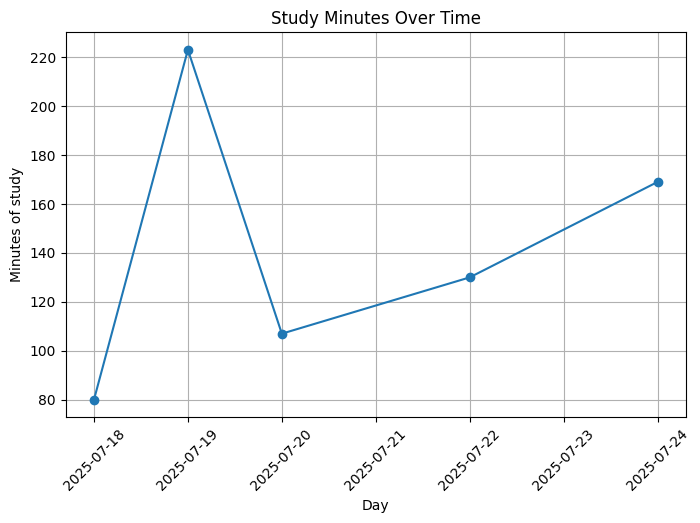

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(df['DAY'], df['minutes'], marker='o')
plt.xlabel('Day')
plt.ylabel('Minutes of study')
plt.title('Study Minutes Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [8]:
df['growth_rate (%)'] = (
    df['minutes']
    .replace(0, pd.NA)     # Treat 0 as missing
    .pct_change() * 100
)

df['growth_rate (%)'] = df['growth_rate (%)'].replace([np.inf, -np.inf], pd.NA).fillna(0)

print(df[['growth_rate (%)']].round(2))

   growth_rate (%)
0             0.00
1           178.75
2           -52.02
3            21.50
4            30.00


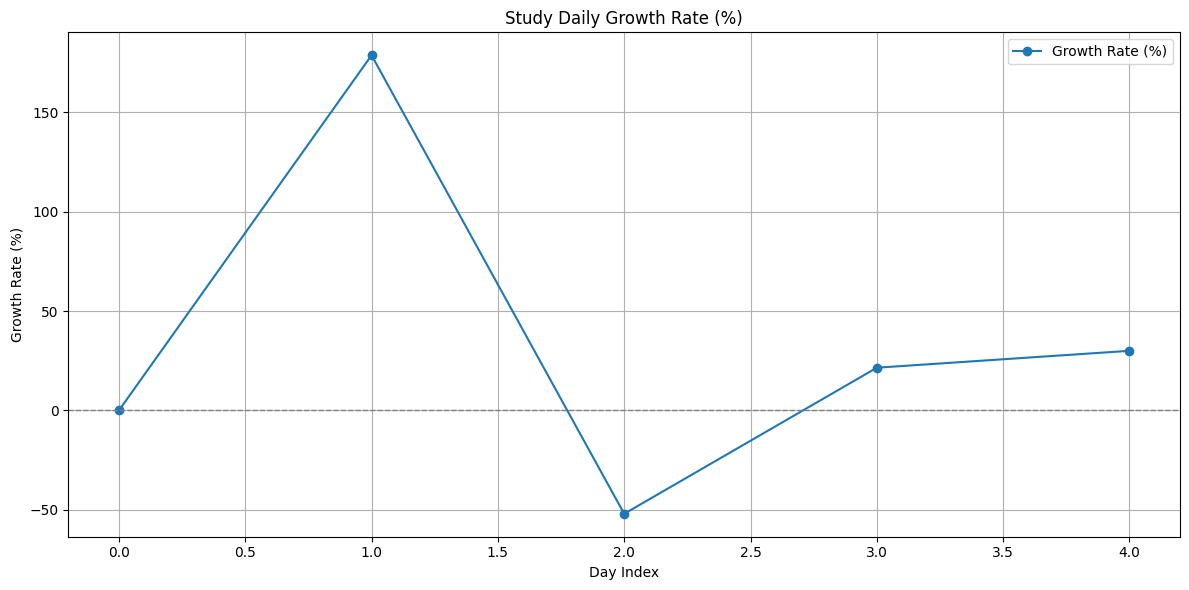

In [9]:
df['growth_rate (%)'] = df['growth_rate (%)'].round(2)

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['growth_rate (%)'], marker='o', linestyle='-', label='Growth Rate (%)')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.title('Study Daily Growth Rate (%)')
plt.xlabel('Day Index')
plt.ylabel('Growth Rate (%)')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [10]:
valid_minutes = df['minutes'].replace(0, pd.NA).dropna()

if not valid_minutes.empty:
    initial = valid_minutes.iloc[0]
    final = valid_minutes.iloc[-1]
    overall_growth = ((final - initial) / initial) * 100
    print(f"Overall growth rate from start to end: {overall_growth:.2f}%")
else:
    print("Not enough valid data to calculate growth.")

Overall growth rate from start to end: 111.25%


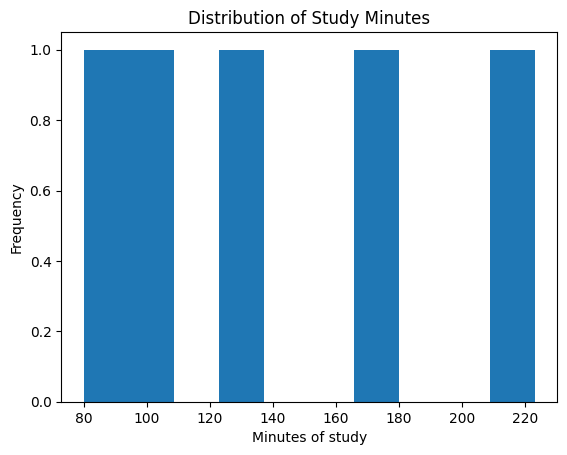

In [11]:
df['minutes'].plot.hist()
plt.xlabel("Minutes of study")
plt.title("Distribution of Study Minutes")
plt.show()